# Supporting 5 - Worked example: inputs -> simulation -> prediction -> evaluation

*Optional detail; start with `notebooks/00_START_HERE.ipynb`.*

Input file: `examples/worked_example_input.json` (assumed generic values, not a real site). The same steps are available from the command line:

```
subsurfaceml simulate --config config/demo.yaml --input examples/worked_example_input.json
subsurfaceml predict  --config config/demo.yaml --input examples/worked_example_input.json
```

In [1]:
import sys, json, time
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from subsurfaceml.config import load_config

CONFIG = 'demo'                 # which completed run this notebook reads
cfg = load_config(ROOT / 'config' / f'{CONFIG}.yaml')
S = json.loads((Path(cfg.paths.metrics) / 'summary.json').read_text())
pd.set_option('display.max_colwidth', 80)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'font.size': 9, 'figure.constrained_layout.use': True})


def provenance(kind, what):
    """Label every result: read from a finished run, or computed right here."""
    label = {'loaded': 'LOADED from the completed ' + CONFIG + ' run',
             'computed': 'COMPUTED NOW in this notebook session'}[kind]
    print(f'[{label}]  {what}')
from subsurfaceml.predict import Predictor, realisation_from_dict
from subsurfaceml.scenarios import make_schedule, run_scenario, reference_rate
from subsurfaceml.features import raw_inputs, features_for_schedules
from subsurfaceml.units import MPA, YEAR
case = json.loads((ROOT/'examples/worked_example_input.json').read_text())
r = realisation_from_dict(case['reservoir']); rates = np.array(case['rates_kg_s'])
print(r); print('rates [kg/s]:', rates)

Realisation(realisation_id=-1, seed=12345, k_median_mD=150.0, V_DP=0.6, phi_mean=0.2, h_total_m=40.0, r_e_m=2500.0, n_g=2.0, n_a=3.0, krg0=0.45, S_ar=0.25, mu_g_cP=0.06, rho_g=700.0)
rates [kg/s]: [5.  4.5 3.5 3. ]


## Step 1 - inputs the surrogate sees (the single feature path)

`raw_inputs` builds the layered rock with the realisation's seed, the closed-form reference rate and the end-point mobility ratio with this reservoir's own `krg0`; `engineer` adds log-transforms, flow capacity, pore volume and schedule-shape descriptors.

In [2]:
raw = raw_inputs(cfg, r, rates)
print({k: raw[k] for k in ('V_DP_layers','q_ref_kg_s','endpoint_mobility_ratio','planned_mass_kg')})
X = features_for_schedules(cfg, r, rates[None, :]); display(X.T.rename(columns={0: 'value'}))

{'V_DP_layers': 0.6543976865347547, 'q_ref_kg_s': 2.7496507187033714, 'endpoint_mobility_ratio': 4.5, 'planned_mass_kg': 631152000.0}


,value
log10_k_mD,2.176091e+00
V_DP,6.000000e-01
phi_mean,2.000000e-01
h_total_m,4.000000e+01
r_e_m,2.500000e+03
n_g,2.000000e+00
n_a,3.000000e+00
krg0,4.500000e-01
S_ar,2.500000e-01
mu_g_cP,6.000000e-02


## Step 2 - simulate (the reference answer)

{'dp_bh_max_MPa': 7.005074557611346, 'r_plume_m95_m': 298.3059798517422, 'sweep_efficiency': 0.01675000641885279} | wall time 0.56 s | mass balance 0.0


Text(0, 0.5, 'Plume radius, 95 % of mass [m]')

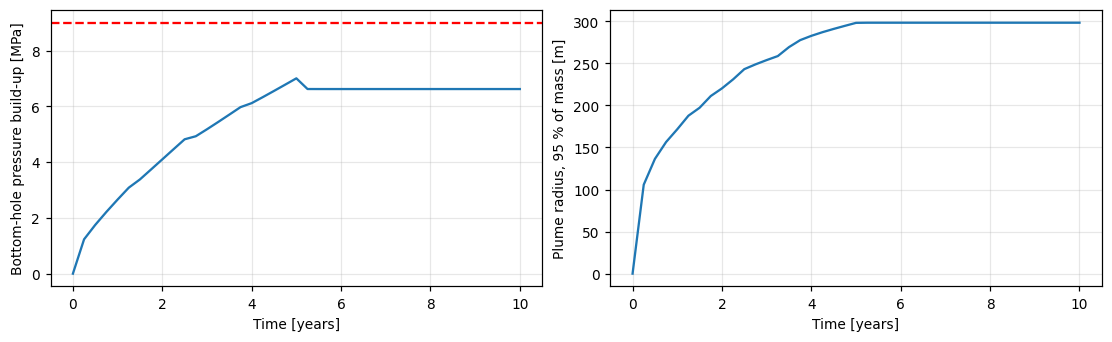

In [3]:
o = run_scenario(cfg, r, make_schedule(cfg, r, rates), want_series=True)
w, ts = o['row'], o['series']
sim = {'dp_bh_max_MPa': w['dp_bh_max_Pa']/MPA, 'r_plume_m95_m': w['r_plume_m95_m'],
       'sweep_efficiency': w['sweep_efficiency']}
print(sim, '| wall time', round(w['wall_time_s'], 2), 's | mass balance', w['mass_balance_error'])
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(ts.t_s/YEAR, ts.dp_bh_Pa/MPA); ax[0].axhline(cfg.optim.p_limit_MPa-cfg.solver.p_init_MPa, c='r', ls='--')
ax[0].set_xlabel('Time [years]'); ax[0].set_ylabel('Bottom-hole pressure build-up [MPa]')
ax[1].plot(ts.t_s/YEAR, ts.r_plume_m95_m); ax[1].set_xlabel('Time [years]'); ax[1].set_ylabel('Plume radius, 95 % of mass [m]')

## Step 3 - predict with the saved surrogates

In [4]:
P = Predictor(cfg)
out = P.predict(r, rates[None, :])
rows = []
for t in sim:
    o_ = out[t]; p, lo, hi = o_['pred'][0], o_['band_low'][0], o_['band_high'][0]
    rows.append({'quantity': t, 'simulated': sim[t], 'predicted': p, 'error': p - sim[t],
                 'relative error %': 100*(p - sim[t])/sim[t], 'interval low': lo, 'interval high': hi,
                 'inside interval': lo <= sim[t] <= hi, 'unit': o_['unit']})
display(pd.DataFrame(rows))
e = out['exceeds_pressure_limit']
print('classifier flag (exceeds limit):', bool(e['flag'][0]), '| simulated exceedance:',
      sim['dp_bh_max_MPa'] > e['dp_limit_MPa'])

,quantity,simulated,predicted,error,relative error %,interval low,interval high,inside interval,unit
0,dp_bh_max_MPa,7.005075,6.964403,-0.040671,-0.580598,6.337075,7.653832,True,MPa
1,r_plume_m95_m,298.305980,308.423318,10.117338,3.391598,291.407234,326.433019,True,m
2,sweep_efficiency,0.016750,0.016358,-0.000392,-2.338482,0.012671,0.020046,True,-


classifier flag (exceeds limit): False | simulated exceedance: False


## Step 4 - evaluate: how does this case compare with the test-set error?

In [5]:
for t in sim:
    te = S['ml']['targets'][t]['test']
    print(f"{t}: this case |error| = {abs(out[t]['pred'][0]-sim[t]):.4g}; test MAE {te['MAE']:.4g}, "
          f"max {te['max_abs_error']:.4g} {S['ml']['targets'][t]['unit']}")
print('in the training domain:', bool(out['in_training_domain'][0]))

dp_bh_max_MPa: this case |error| = 0.04067; test MAE 0.1656, max 4.231 MPa
r_plume_m95_m: this case |error| = 10.12; test MAE 8.008, max 64.38 m
sweep_efficiency: this case |error| = 0.0003917; test MAE 0.001232, max 0.007094 -
in the training domain: True


**Reading this result.** The table compares one simulated case with the surrogates' predictions and intervals. A prediction outside its interval is expected now and then -- for nominal 90 % intervals roughly one case in ten, and more often for a reservoir unlike the calibration reservoirs, which the domain flag reports. This is why the screening never relies on a prediction alone: any schedule that matters is simulated first.

## Step 5 - what-if: scale the whole schedule

Text(0, 0.5, 'Predicted peak build-up [MPa]')

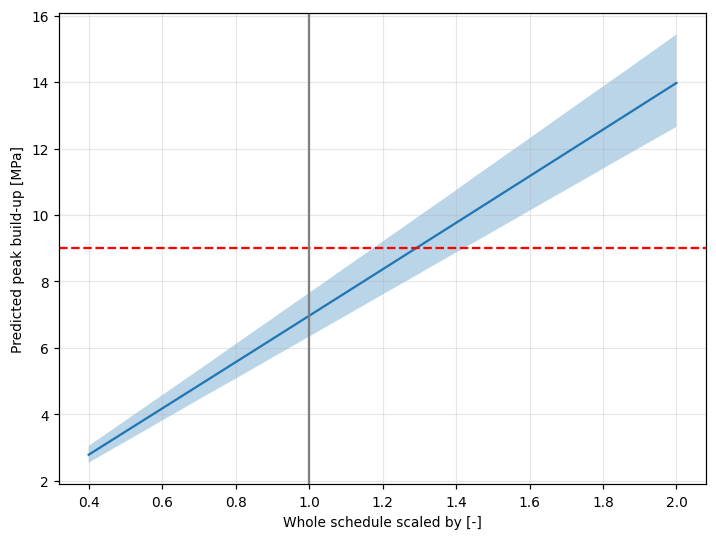

In [6]:
f = np.linspace(.4, 2, 33)
pred = P.predict(r, np.outer(f, rates))['dp_bh_max_MPa']
plt.plot(f, pred['pred']); plt.fill_between(f, pred['band_low'], pred['band_high'], alpha=.3)
plt.axhline(cfg.optim.p_limit_MPa-cfg.solver.p_init_MPa, c='r', ls='--'); plt.axvline(1, c='grey')
plt.xlabel('Whole schedule scaled by [-]'); plt.ylabel('Predicted peak build-up [MPa]')